<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Efficientnet_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input # CRITICAL FIX
from sklearn.utils import class_weight # For balancing
import matplotlib.pyplot as plt
import numpy as np
import os

In [8]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_finetuned_ver2.keras'

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 14

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [12]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3577 images belonging to 14 classes.
Found 763 images belonging to 14 classes.


In [13]:
print("\nComputing Class Weights...")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(f"Weights: {class_weights_dict}")


Computing Class Weights...
Weights: {0: np.float64(0.998046875), 1: np.float64(1.0780590717299579), 2: np.float64(0.9324817518248175), 3: np.float64(1.0179282868525896), 4: np.float64(0.9569288389513109), 5: np.float64(0.9462962962962963), 6: np.float64(1.0735294117647058), 7: np.float64(1.0557851239669422), 8: np.float64(1.0179282868525896), 9: np.float64(0.9533582089552238), 10: np.float64(0.9428044280442804), 11: np.float64(1.0872340425531914), 12: np.float64(1.0179282868525896), 13: np.float64(0.9605263157894737)}


In [14]:
# Building the model
print("\nBuilding Model...")

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

for layer in base_model.layers[:200]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(), # Stabilizes training
    layers.Dropout(0.3),         # Increased dropout slightly for robustness
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Building Model...
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
# Feature Extraction
print("\n--- STAGE 1: Training Head (Backbone Frozen) ---")

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_stage1 = model.fit(
    train_generator,
    epochs=20, # Short run just to train the head
    validation_data=val_generator,
    class_weight=class_weights_dict, # Apply weights
    callbacks=[early_stopping],
    verbose=1
)


--- STAGE 1: Training Head (Backbone Frozen) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3794s 34s/step - accuracy: 0.5254 - loss: 1.5723 - val_accuracy: 0.8480 - val_loss: 0.6053
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.8099 - loss: 0.6030 - val_accuracy: 0.8716 - val_loss: 0.4226
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 475ms/step - accuracy: 0.8548 - loss: 0.4562 - val_accuracy: 0.8899 - val_loss: 0.3549
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 475ms/step - accuracy: 0.8795 - loss: 0.3682 - val_accuracy: 0.8807 - val_loss: 0.4062
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 477ms/step - accuracy: 0.8888 - loss: 0.3392 - val_accuracy: 0.8820 - val_loss: 0.3863
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.9058 - loss: 0.3055 - val_accuracy: 0.9305 - val_loss: 0.2213
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.9157 - loss: 0.2876 - val_accuracy: 0.9148 - val_loss: 0.2895
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.9251 - loss: 0

In [16]:
print("\n--- STAGE 2: Fine-Tuning (Backbone Unfrozen) ---")

# Unfreeze the base model
base_model.trainable = True

# Optional: Freeze the bottom N layers if you want to keep edge detectors static
# Set fine-tuning to True

# CRITICAL: Recompile with a very low learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # 10x or 100x smaller than default
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# New callbacks for the long run
early_stopping_ft = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath=SAVE_PATH, save_best_only=True, monitor='val_loss')

history_fine = model.fit(
    train_generator,
    epochs=100, # Long run
    initial_epoch=history_stage1.epoch[-1], # Resume where Stage 1 left off
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_ft, model_checkpoint],
    verbose=1
)


--- STAGE 2: Fine-Tuning (Backbone Unfrozen) ---
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 121s 759ms/step - accuracy: 0.9301 - loss: 0.2298 - val_accuracy: 0.9345 - val_loss: 0.2111
Epoch 12/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 481ms/step - accuracy: 0.9358 - loss: 0.2148 - val_accuracy: 0.9397 - val_loss: 0.2006
Epoch 13/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - accuracy: 0.9514 - loss: 0.1775 - val_accuracy: 0.9384 - val_loss: 0.1997
Epoch 14/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 488ms/step - accuracy: 0.9364 - loss: 0.1947 - val_accuracy: 0.9463 - val_loss: 0.1932
Epoch 15/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 492ms/step - accuracy: 0.9428 - loss: 0.1992 - val_accuracy: 0.9463 - val_loss: 0.1875
Epoch 16/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - accuracy: 0.9459 - loss: 0.1886 - val_accuracy: 0.9515 - val_loss: 0.1798
Epoch 17/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 494ms/step - accuracy: 0.9305 - loss: 0.2202 - val_accuracy: 0.9476 - val_loss: 0.1794
Epoch 18/100
112/1

In [17]:
def plot_full_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(12, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Acc')
    plt.plot(val_acc, label='Validation Acc')
    # Draw line where fine-tuning started
    plt.plot([len(h1.history['accuracy'])-1, len(h1.history['accuracy'])-1],
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('EffecientNet - Training and Validation Accuracy')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.plot([len(h1.history['loss'])-1, len(h1.history['loss'])-1],
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('EffecientNet - Training and Validation Loss')
    plt.show()


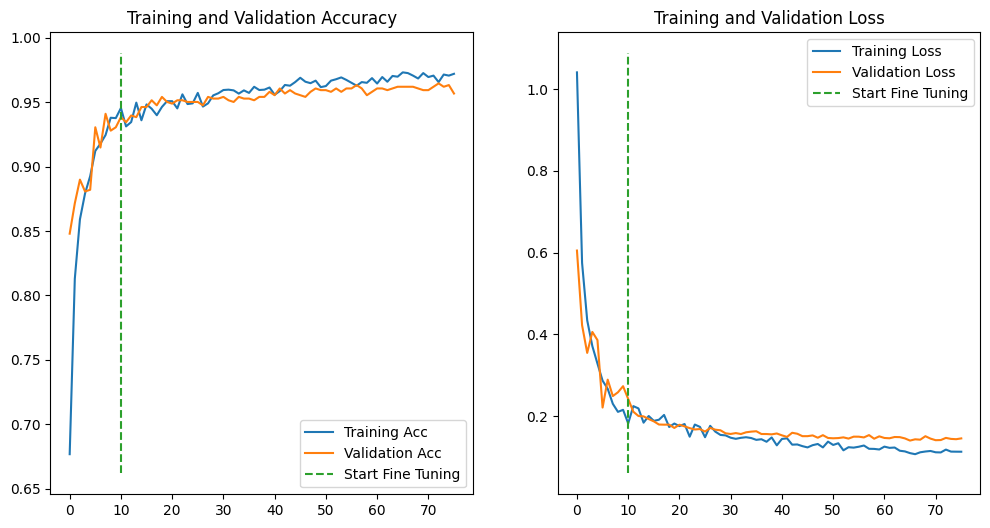

In [18]:
plot_full_history(history_stage1, history_fine)